In [99]:
import numpy as np
import networkx as nx
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [100]:
def continuous_dynamics(t, x_vec, A, B, D):
    #this is just the continuous time SIS networked model dynamics
    dx_dt = -D @ x_vec[:-1] + (np.eye(A.shape[0]) - np.diag(x_vec[:-1])) @ B @ A @ x_vec[:-1]
    #also have a dummy variable forthe cost function, since we are minimizing
    # - sum_{i = 1}^N \integral x_i(t) over the time horizon
    di_dt = np.sum(x_vec[:-1])
    return np.concatenate((dx_dt, [di_dt]))

#This function should simulate the continuous dynamics over a time horizon
#returns the cost we want to minimize
def simulate_horizon(update_list, H, x_vec_0, A, B, D, tau_k, customer_groups):
    #initialize the simulation variables
    current_x_vec = x_vec_0
    current_B = B
    current_D = D
    current_integral= 0
    current_t = tau_k

    final_time = tau_k + H
    start_time = tau_k
    #do this because the optimizer can choose update times that are not in the right order
    update_list = np.sort(update_list)
    #add these to the update list to make it easier to handle the intervals (if they arent already there)
    if start_time not in update_list:
        update_list = np.concatenate(([start_time], update_list))
    if final_time not in update_list:
        update_list = np.append(update_list, final_time)
    #simulate the dynamics over the time horizon
    m = len(update_list) # not really m all the time since technically we added start and end time
    for i in range(m - 1):
        t_start = update_list[i]
        t_end = update_list[i + 1]
        #make sure each interval has a positive length
        # if t_end == t_start:
        #     continue
        if np.isclose(t_end, t_start):
            continue
        #now simulate the dynamics: 
        sol = solve_ivp(continuous_dynamics,
                                [t_start, t_end], 
                                np.concatenate((current_x_vec, [current_integral])), 
                                args=(A, current_B, current_D), 
                                dense_output=False
                                #Im just setting this to false for now since it returns an array hich is easier to handlke
                )
        if not sol.success:
            raise RuntimeError(sol.message)
        current_x_vec = sol.y[:-1, -1] #get the last state from this time interval
        current_integral = sol.y[-1, -1] #get the last integral value from this time interval
        delta_t = t_end - t_start #time since the last update
        #APPLY THE DISCRETE JUMPS HERE (each group has a different discrete jump function)
        current_x_vec = f(customer_groups, current_x_vec, A, delta_t)

    return current_integral, current_x_vec, sol.y, sol.t

#given a start time do NMPC over the time horizon
def interval_NMPC(x_vec, A, B, D, H, m, tau_k, customer_groups):
    def objective(u):
        #simulate the dynamics over the time horizon
        cost, _, _, _ = simulate_horizon(u, H, x_vec, A, B, D, tau_k, customer_groups)
        return -1 * cost #because we minimizing
    update_list_guess = np.linspace(tau_k, tau_k + H, m+2)
    update_list_guess = update_list_guess[1:-1] #remove the first and last elements since they are fixed
    bounds = [(tau_k, tau_k + H) for _ in range(m)]
    # result = minimize(
    #     objective,
    #     update_list_guess,
    #     bounds=bounds,
    #     method='SLSQP',
    #     options={'disp': False} #dont need the messages and stuff, letit do its thing
    # )
    #This is a derivative free optimization method recommended from gemini, since our objective function has jumps
    result = minimize(
        objective,
        update_list_guess,
        bounds=bounds,
        method='Powell', # Swapped to a derivative-free directional search
        options={'disp': False} 
    )
    return result


def f(customer_groups, current_x_vec, A, delta_t):
    # Store the state before any updates are applied
    old_state = current_x_vec.copy()

    # This will hold the updated state
    new_state = old_state.copy()

    # Get parameters for each group and apply the discrete jump function
    for group_name, (indices, (g, u, p_max)) in customer_groups.items():

        # Compute the time-based boost once for this group
        update_boost = g**2 / ((delta_t - u)**2 + g**2)

        # Apply the update to each node in the group
        for i in indices:

            # Find neighbors
            all_neighbors = np.where(A[i] != 0)[0].tolist()

            # Neighbors in the same customer group
            same_group_neighbors = [j for j in all_neighbors if j in indices]

            # Read infection levels from the OLD state
            same_group_infection_levels = old_state[same_group_neighbors]
            all_neighbors_infection_levels = old_state[all_neighbors]

            total_neighbor_infection = np.sum(all_neighbors_infection_levels)

            if total_neighbor_infection > 0:
                neighbor_boost = (
                    np.sum(same_group_infection_levels)
                    / total_neighbor_infection
                )
            else:
                neighbor_boost = 0.0

            coeff = 1 * (update_boost + neighbor_boost) * p_max

            # Write into the NEW state
            new_state[i] = min(coeff * old_state[i], 1.0)

    return new_state


def NMPC_simulation(x_vec_0, A, B, D, H, m, total_time, customer_groups):
    #initialize the sim variables
    current_x_vec = x_vec_0
    current_t = 0
    x_vec_history = []
    t_history = []

    current_B = B
    current_D = D
    #run the NMPC simulation
    while current_t < total_time:
        #run the NMPC optimization to get the optimal update times
        result = interval_NMPC(current_x_vec, A, B, D, H, m, current_t, customer_groups)
        optimal_update_times = result.x
        optimal_update_times = np.sort(result.x) #sort to keep the order of update times
        future_updates = optimal_update_times[optimal_update_times > current_t + 1e-5]
        
        if len(future_updates) > 0:
            next_update_time = future_updates[0]
        else:
            # Fallback: If no future updates are found in the horizon, step forward by H
            next_update_time = current_t + H 
            
        # Ensure we don't simulate past the total_time limit
        next_update_time = min(next_update_time, total_time)
        
        #simulate just to the next update time
        #now simulate the dynamics ONLY to the next update time
        solve_ivp_result = solve_ivp(continuous_dynamics,
                                     [current_t, next_update_time],
                                     np.concatenate((current_x_vec, [0])), #the last element is the integral, but we dont care about it here
                                     args=(A, B, D), 
                                        dense_output=False
                                        )
        if not solve_ivp_result.success:
            raise RuntimeError(solve_ivp_result.message)
        #Get the histories for plotting
        interval_state_history = solve_ivp_result.y[:-1, :] #get the state history from this time interval
        interval_time_history = solve_ivp_result.t #get the time history from this time interval
        #append the state and time history to the overall history
        x_vec_history.append(interval_state_history.T) #transpose to get the right shape
        t_history.append(interval_time_history)

        #APPLY THE DISCRETE JUMPS HERE (each group has a different discrete jump function)
        delta_t = next_update_time - current_t #time since the last update
        current_x_vec = solve_ivp_result.y[:-1, -1] #get the last state from this time interval
        current_x_vec = f(customer_groups, current_x_vec, A, delta_t)


        #update variables for the next iteration
        current_t = next_update_time
        





    return np.concatenate(x_vec_history, axis=0), np.concatenate(t_history, axis=0) #return the state and time histories




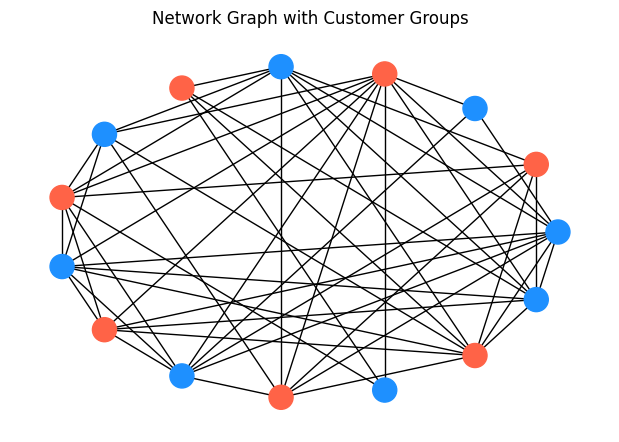

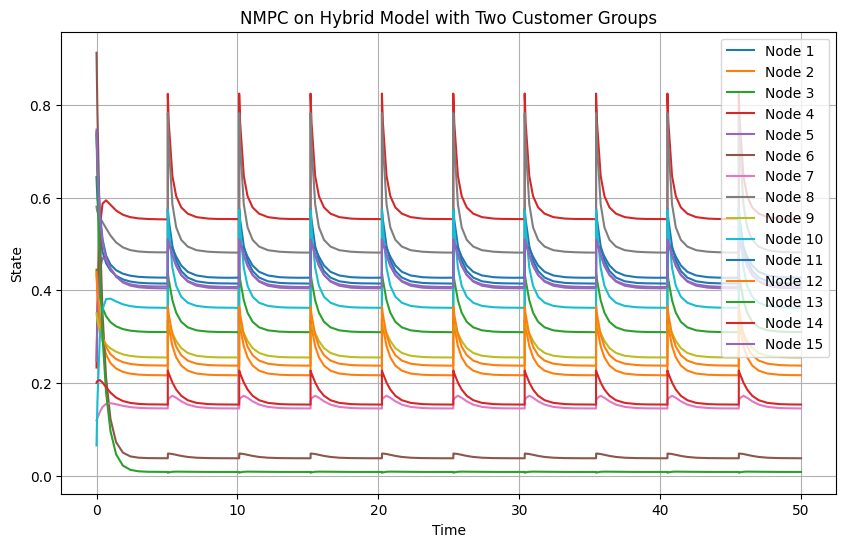

In [101]:
#sim parameters
H  = 10
#network parameters
#make a dictionary to handle the groups (different types of customers)
g1 = 10 #determines how wide the bell curve is
u1 = 5 #determines the center of the bell curve 
p_max1 = 1.1 #make boost someone can have
g2 = 5 
u2 = 8
p_max2 = 1.05


#make the adjacency matrix for the network ER graph
n = 15 #number nodes
p = 0.5
Graph = nx.erdos_renyi_graph(n, p, seed=42)
x_vec_0 = np.random.uniform(0, 1, n) 
D = np.diag(np.random.uniform(2, 3, n))
B = np.diag(np.random.uniform(0, 1, n))

#make a list of odd and even nodes for grouping
odd_nodes = [i for i in range(n) if i % 2 == 1]
even_nodes = [i for i in range(n) if i % 2 == 0]
customer_groups = {"Group 1": (odd_nodes, [g1, u1, p_max1]), "Group 2": (even_nodes, [g2, u2, p_max2])} #each group is a list of the index of the nodes in that group 


#plot the graph that the spreading is ocurring on and label the nodes as group 1 or group 2
pos = nx.circular_layout(Graph)
plt.figure(figsize=(6, 4))

node_colors = ['gray'] * Graph.number_of_nodes()
group_colors = ['tomato', 'dodgerblue'] 

for color, (group_name, (nodes, _)) in zip(group_colors, customer_groups.items()):
    for node in nodes:
        node_colors[node] = color

nx.draw(Graph, pos, with_labels=False, node_color=node_colors, node_size=300)

plt.title('Network Graph with Customer Groups')
plt.show()

state_history, time_history = NMPC_simulation(x_vec_0, nx.to_numpy_array(Graph), B, D, H, m=2, total_time=50, customer_groups = customer_groups)
#plot the results
plt.figure(figsize=(10, 6))
for i in range(n):
    plt.plot(time_history, state_history[:, i], label=f'Node {i+1}')
plt.xlabel('Time')
plt.ylabel('State')
plt.title('NMPC on Hybrid Model with Two Customer Groups')
plt.legend()
plt.grid()
plt.show()